In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lecture des données du dossier data
df = pd.read_csv('../data/train.csv')

# 2. Affichage des 5 premières lignes pour voir les données de nos propres yeux
print("--- Cinq premières lignes ---")
display(df.head())

# 3. Connaissance des noms des colonnes et de leurs types (numerical vs categorical)
print("\n--- Informations générales sur les colonnes ---")
df.info()

--- Cinq premières lignes ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Informations générales sur les colonnes ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual   

In [5]:
# Calcul du nombre de valeurs manquantes et de leur pourcentage
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100

# Rassemblement des résultats dans un seul tableau pour que l'image soit claire
missing_df = pd.concat([null_counts, null_percent], axis=1, keys=['Total', 'Percent'])

# Tri du plus grand au plus petit et affichage des 20 premiers
missing_df.sort_values('Total', ascending=False).head(20)

,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


In [6]:
# 1. Suppression des colonnes avec plus de 40% de valeurs manquantes
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
df_cleaned = df.drop(columns=cols_to_drop)

# 2. Remplacement des valeurs manquantes dans les colonnes numériques par la moyenne (Mean)
# Par exemple LotFrontage a 17% de valeurs manquantes, nous allons le remplacer par la moyenne
df_cleaned['LotFrontage'] = df_cleaned['LotFrontage'].fillna(df_cleaned['LotFrontage'].mean())

# 3. Vérification s'il reste encore des valeurs manquantes importantes
print("Colonnes restantes avec des valeurs manquantes :")
print(df_cleaned.isnull().sum().sort_values(ascending=False).head(10))

Colonnes restantes avec des valeurs manquantes :
GarageType      81
GarageYrBlt     81
GarageQual      81
GarageCond      81
GarageFinish    81
BsmtFinType2    38
BsmtExposure    38
BsmtQual        37
BsmtFinType1    37
BsmtCond        37
dtype: int64


In [7]:
# 1. Remplacement des valeurs manquantes dans les colonnes du garage (Garage)
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in garage_cols:
    df_cleaned[col] = df_cleaned[col].fillna('None')

df_cleaned['GarageYrBlt'] = df_cleaned['GarageYrBlt'].fillna(0)

# 2. Remplacement des valeurs manquantes dans les colonnes du sous-sol (Basement)
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in bsmt_cols:
    df_cleaned[col] = df_cleaned[col].fillna('None')

# 3. Vérification finale s'il reste des valeurs manquantes
print("Nombre total de valeurs manquantes dans toutes les données :")
print(df_cleaned.isnull().sum().sum())

Nombre total de valeurs manquantes dans toutes les données :
9


In [8]:
# Remplacement de toute valeur numérique par 0 et de toute valeur textuelle par "None"
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].fillna('None')
    else:
        df_cleaned[col] = df_cleaned[col].fillna(0)

print(f"Nombre total final de valeurs manquantes : {df_cleaned.isnull().sum().sum()}")

Nombre total final de valeurs manquantes : 0


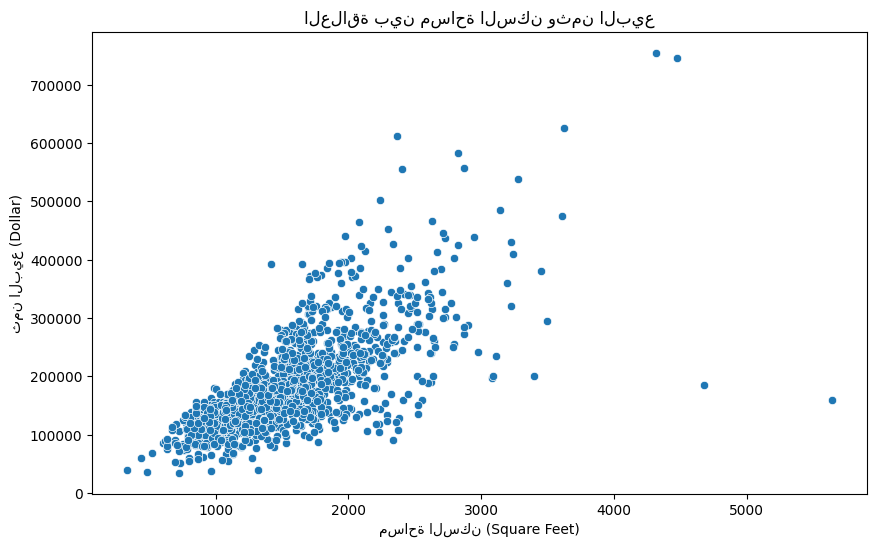

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_cleaned['GrLivArea'], y=df_cleaned['SalePrice'])
plt.title('Relation entre la surface habitable et le prix de vente')
plt.xlabel('Surface habitable (Square Feet)')
plt.ylabel('Prix de vente (Dollar)')
plt.show()

In [10]:

# Conversion de toutes les colonnes textuelles en nombres
df_final = pd.get_dummies(df_cleaned)

# Affichage de la nouvelle taille des données (vous remarquerez que le nombre de colonnes a beaucoup augmenté)
print(f"Ancienne taille : {df_cleaned.shape}")
print(f"Nouvelle taille après conversion : {df_final.shape}")

# Affichage des 5 premières lignes des données finales
df_final.head()

Ancienne taille : (1460, 75)
Nouvelle taille après conversion : (1460, 278)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False


In [11]:
from sklearn.model_selection import train_test_split

# 1. Isolation des "caractéristiques" (X) de "le prix" (y)
X = df_final.drop('SalePrice', axis=1) # Toutes les colonnes sauf le prix
y = df_final['SalePrice']              # Seulement le prix

# 2. Division des données : 80% pour l'apprentissage et 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Nombre de maisons pour l'apprentissage : {len(X_train)}")
print(f"Nombre de maisons pour le test : {len(X_test)}")

Nombre de maisons pour l'apprentissage : 1168
Nombre de maisons pour le test : 292


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Création du Model (on lui demande de construire 100 arbres)
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Opération d"entraînement" (Fit) - ici l'IA commence à lire 1168 maisons
print("Entraînement en cours... patience un peu")
model.fit(X_train, y_train)
print("Entraînement terminé avec succès !")

# 3. Maintenant nous le laissons passer "l'examen" (Prédiction)
preds = model.predict(X_test)

# 4. Voyons quel est le "taux d'erreur" (MAE)
score = mean_absolute_error(y_test, preds)
print(f"Taux d'erreur (MAE) : {score:.2f} dollars")

Entraînement en cours... patience un peu
Entraînement terminé avec succès !
Taux d'erreur (MAE) : 17746.48 dollars


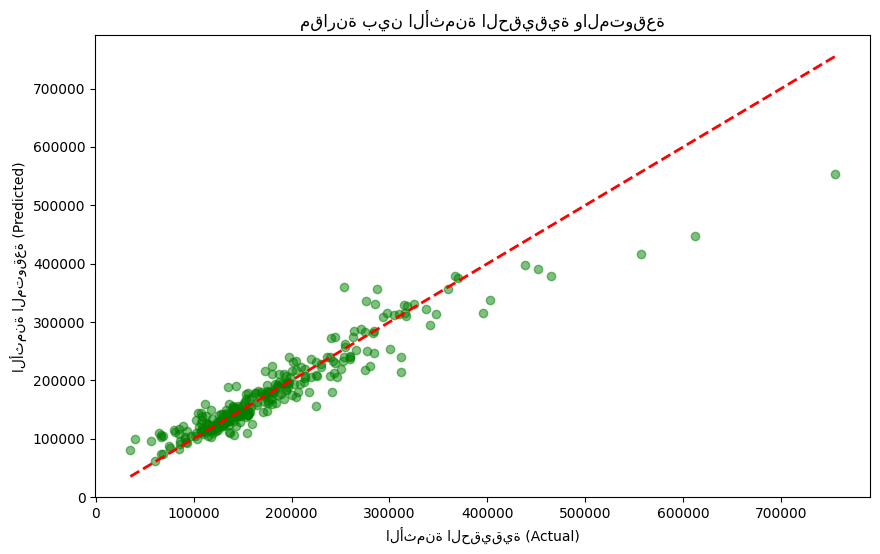

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Prix réels (Actual)')
plt.ylabel('Prix prédits (Predicted)')
plt.title('Comparaison entre les prix réels et prédits')
plt.show()

In [16]:
# 1. Lecture des données de test (test.csv)
test_data = pd.read_csv('../data/test.csv')
test_ids = test_data['Id'] # Nous sauvegardons les IDs car nous en aurons besoin dans le fichier final

# 2. Nettoyage des données de test (mêmes étapes que pour train)
test_data_cleaned = test_data.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'])

# Remplacement des valeurs manquantes
for col in test_data_cleaned.columns:
    if test_data_cleaned[col].dtype == 'object':
        test_data_cleaned[col] = test_data_cleaned[col].fillna('None')
    else:
        test_data_cleaned[col] = test_data_cleaned[col].fillna(0)

# 3. Conversion des textes en nombres
test_final = pd.get_dummies(test_data_cleaned)

# 4. "Alignement" (Alignment) - c'est l'étape la plus importante !
# Nous nous assurons que test a exactement les mêmes colonnes que train
test_final = test_final.reindex(columns = X.columns, fill_value=0)

# 5. Prédiction finale
final_preds = model.predict(test_final)

# 6. Création du fichier Submission
output = pd.DataFrame({'Id': test_ids, 'SalePrice': final_preds})
output.to_csv('../data/submission.csv', index=False)

print("Fichier prêt ! Vous le trouverez maintenant dans le dossier data/submission.csv")

Fichier prêt ! Vous le trouverez maintenant dans le dossier data/submission.csv
